# Preparing and visualization

## preview

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
data=pd.read_csv('data/wage.csv')
data.head(10)

,year,age,sex,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Male,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Male,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,1. Male,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,1. Male,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,1. Male,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
5,2008,54,1. Male,2. Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.845098,127.115744
6,2009,44,1. Male,2. Married,4. Other,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.133021,169.528538
7,2008,30,1. Male,1. Never Married,3. Asian,3. Some College,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.716003,111.720849
8,2006,41,1. Male,1. Never Married,2. Black,3. Some College,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.778151,118.884359
9,2004,52,1. Male,2. Married,1. White,2. HS Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.857332,128.680488


In [10]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3000 non-null   int64  
 1   age         3000 non-null   int64  
 2   sex         3000 non-null   object 
 3   maritl      3000 non-null   object 
 4   race        3000 non-null   object 
 5   education   3000 non-null   object 
 6   region      3000 non-null   object 
 7   jobclass    3000 non-null   object 
 8   health      3000 non-null   object 
 9   health_ins  3000 non-null   object 
 10  logwage     3000 non-null   float64
 11  wage        3000 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 281.4+ KB


,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430


## reshape

In [15]:
# reshape the data
d_edu=data.pivot(columns='education',values='wage') # parameter: index,aggfunc; similar: pivot_table
d_edu.head(10)

education,1. < HS Grad,2. HS Grad,3. Some College,4. College Grad,5. Advanced Degree
0,75.043154,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,70.476020,NaN
2,NaN,NaN,130.982177,NaN,NaN
3,NaN,NaN,NaN,154.685293,NaN
4,NaN,75.043154,NaN,NaN,NaN
5,NaN,NaN,NaN,127.115744,NaN
6,NaN,NaN,169.528538,NaN,NaN
7,NaN,NaN,111.720849,NaN,NaN
8,NaN,NaN,118.884359,NaN,NaN
9,NaN,128.680488,NaN,NaN,NaN


In [ ]:
df_smarket = pd.read_csv('data/smarket.csv')
df_melt=pd.melt(df_smarket,
                id_vars= 'Direction',
                value_vars=['Lag1', 'Lag2', 'Lag3'], # melted one
                var_name='Lag Type', 
                value_name='Pct Change')
df_melt.head()

,Direction,Lag Type,Pct Change
0,Up,Lag1,0.381
1,Up,Lag1,0.959
2,Down,Lag1,1.032
3,Up,Lag1,-0.623
4,Up,Lag1,0.614


## factor encoding

In [ ]:
credit['Female'] = (credit.Gender == 'Female').astype(int)

In [ ]:
dummies = pd.get_dummies(hitters_df_clean[['League', 'Division', 'NewLeague']])

In [ ]:
from sklearn import preprocessing  
le = preprocessing.LabelEncoder()
y = y.apply(le.fit_transform)  

In [85]:
# convert to number
smarket['Up'] = np.where(smarket['Direction'] == 'Up', 1, 0)

## manipulation

In [ ]:
# drop and calculate the correlation
smarket.drop(columns='Direction').corr()
hitters_df_clean = hitters_df.dropna().drop('Unnamed: 0', axis=1)

## Standardization

In [ ]:
from sklearn.preprocessing import scale 
scale(x)

In [ ]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## TT split

In [122]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

## matplotlib.pyplot

### regression and classification

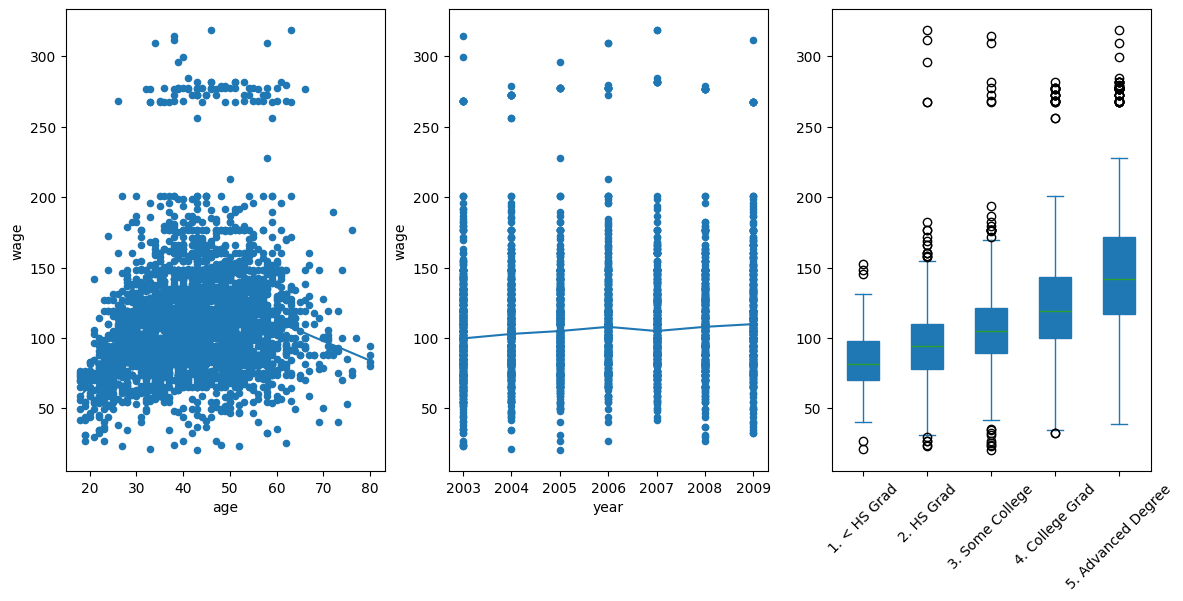

In [20]:
import statsmodels.api as sm

# draw subplot (point and box)
fig,ax=plt.subplots(1,3,figsize=(14,6))
data.plot.scatter('age', 'wage', ax=ax[0])
lowess = sm.nonparametric.lowess(data['wage'], data['age'], frac=.2) #smoothing line
ax[0].plot(lowess[:, 0], lowess[:, 1])

data.plot.scatter('year', 'wage', ax=ax[1])
year_median = data.groupby('year')['wage'].median()
ax[1].plot(year_median)

boxplot = d_edu.plot.box(ax=ax[2], rot=45, patch_artist=True)#set that we have fill
colors = ['lightblue', 'green', 'yellow', 'blue', 'red']
for artist, color in zip(boxplot.artists, colors): # location pair
    artist.set_facecolor(color)
plt.show()

## seaborn

### regression

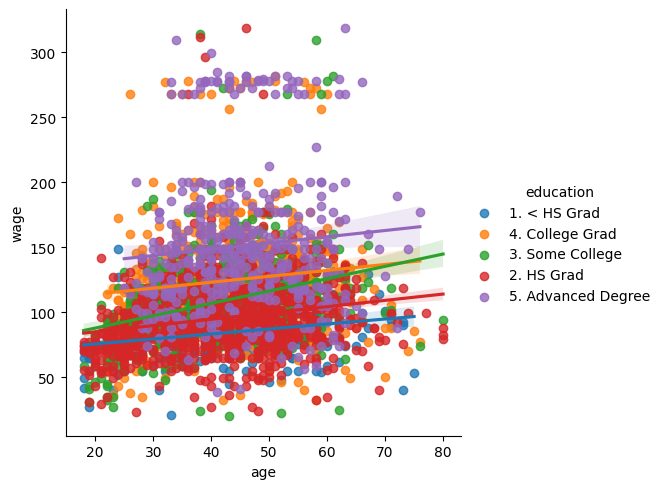

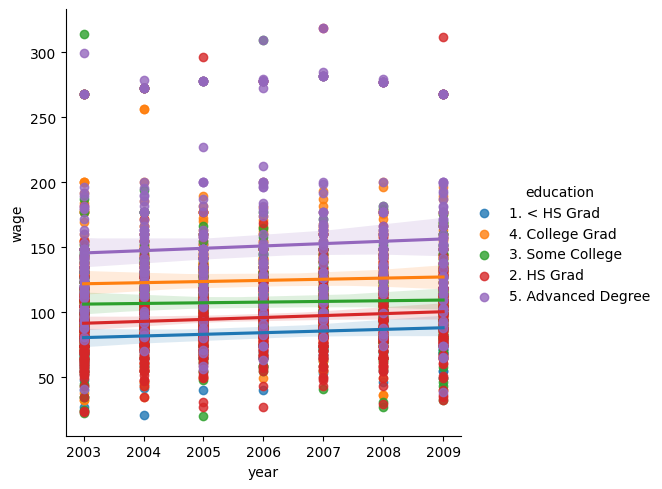

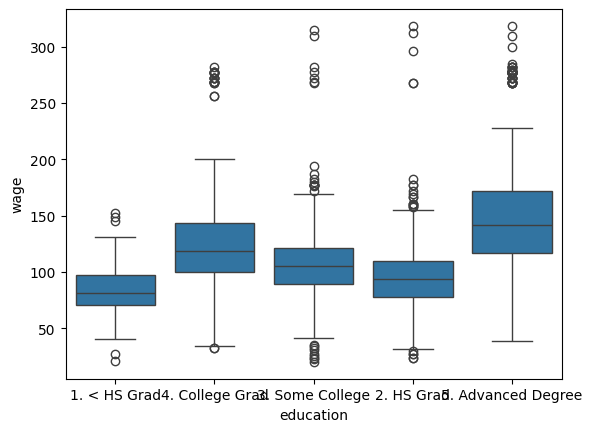

In [32]:
# point, box plot and lm line
import seaborn as sns

sns.lmplot(x='age',y='wage',data=data,hue='education')
sns.lmplot(x='year',y='wage',data=data,hue='education',ci=99.99) # ci means the confidence interval
plt.show()
sns.boxplot(x='education',y='wage',data=data)
plt.show()

### classification

D:\install\anaconda\envs\good\lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


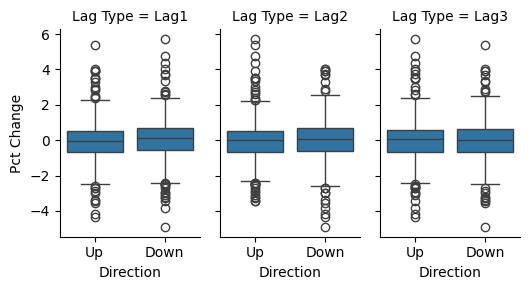

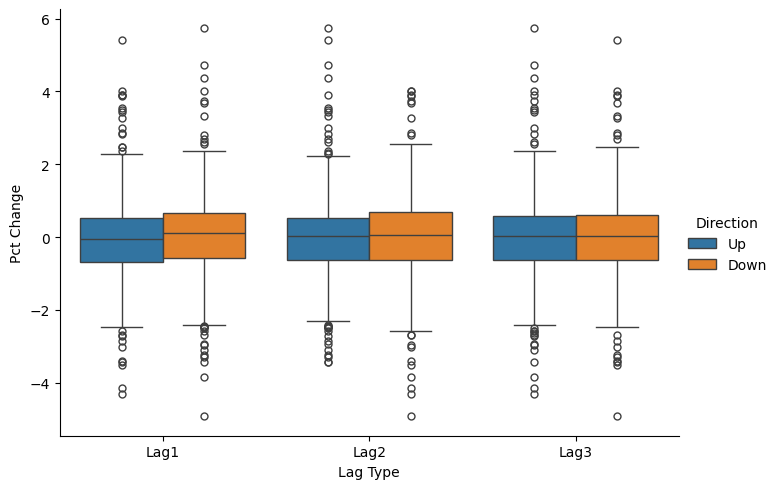

In [43]:
# subplot
g = sns.FacetGrid(df_melt, col="Lag Type", aspect=.6)
g = g.map(sns.boxplot, "Direction", "Pct Change")
plt.show()

# grouped plot
sns.catplot(x="Lag Type", y="Pct Change", hue="Direction",data=df_melt, kind="box", aspect=1.4)
plt.show()

### clustering

In [44]:
df_genes = pd.read_csv('data/nci60_data.csv', index_col=0)
df_genes.head()

,1,2,3,4,5,6,7,8,9,10,...,6821,6822,6823,6824,6825,6826,6827,6828,6829,6830
V1,0.300000,1.180000,0.550000,1.140000,-0.265000,-7.000000e-02,0.350000,-0.315000,-0.450000,-0.654980,...,-0.990020,0.000000,0.030000,-0.175000,0.629981,-0.030000,0.000000,0.280000,-0.340000,-1.930000
V2,0.679961,1.289961,0.169961,0.379961,0.464961,5.799610e-01,0.699961,0.724961,-0.040039,-0.285019,...,-0.270058,-0.300039,-0.250039,-0.535039,0.109941,-0.860039,-1.250049,-0.770039,-0.390039,-2.000039
V3,0.940000,-0.040000,-0.170000,-0.040000,-0.605000,0.000000e+00,0.090000,0.645000,0.430000,0.475019,...,0.319981,0.120000,-0.740000,-0.595000,-0.270020,-0.150000,0.000000,-0.120000,-0.410000,0.000000
V4,0.280000,-0.310000,0.680000,-0.810000,0.625000,-1.387779e-17,0.170000,0.245000,0.020000,0.095019,...,-1.240020,-0.110000,-0.160000,0.095000,-0.350019,-0.300000,-1.150010,1.090000,-0.260000,-1.100000
V5,0.485000,-0.465000,0.395000,0.905000,0.200000,-5.000000e-03,0.085000,0.110000,0.235000,1.490019,...,0.554980,-0.775000,-0.515000,-0.320000,0.634980,0.605000,0.000000,0.745000,0.425000,0.145000


In [45]:
from sklearn.decomposition import PCA
pca=PCA(2) # 2 priciple component
pca_result=pd.DataFrame(pca.fit_transform(df_genes),columns=['pc1','pc2'])
pca_result.head()

,pc1,pc2
0,19.795782,0.115173
1,21.546101,-1.457410
2,25.056622,1.526090
3,37.409536,-11.389515
4,50.218641,-1.346101


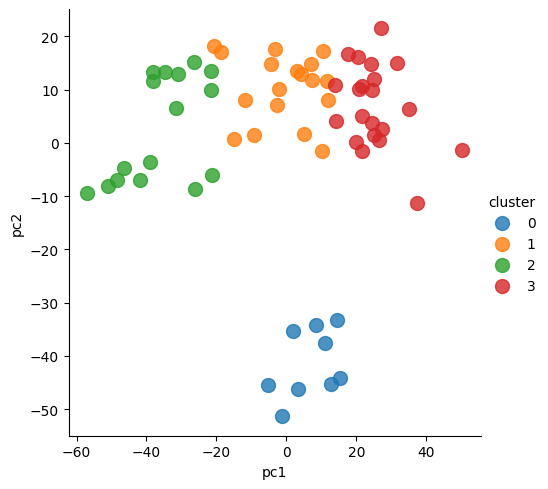

In [48]:
from sklearn.cluster import KMeans
kmeans=KMeans(4)
kmeans.fit(pca_result)
pca_result['cluster']=kmeans.labels_

sns.lmplot(x='pc1', y='pc2', data=pca_result, fit_reg=False, hue='cluster', 
           scatter_kws={"marker": "D", "s": 100})
plt.show()

# Variable selection & reduction (for overfitting)

## FB selection

In [3]:
import itertools
import time
import statsmodels.api as sm

hitters_df = pd.read_csv('data/hitters.csv')
hitters_df_clean = hitters_df.dropna().drop('Unnamed: 0', axis=1)
dummies = pd.get_dummies(hitters_df_clean[['League', 'Division', 'NewLeague']])

y = hitters_df_clean.Salary
X_ = hitters_df_clean.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)

In [ ]:
def processSubset(feature_set):
    # Fit model on feature_set and calculate RSS
    model = sm.OLS(y,X[list(feature_set)].astype(float))## match your model
    regr = model.fit()
    RSS = ((regr.predict(X[list(feature_set)]) - y) ** 2).sum()
    return {"model":regr, "RSS":RSS}

### Both

In [4]:
def getBest(k):
    
    tic = time.time()
    
    results = []
    
    for combo in itertools.combinations(X.columns, k):
        results.append(processSubset(combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

In [6]:
models_best = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()
for i in range(1,8):
    models_best.loc[i] = getBest(i)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")
print(models_best)

Processed 19 models on 1 predictors in 0.045957326889038086 seconds.
Processed 171 models on 2 predictors in 0.2730574607849121 seconds.
Processed 969 models on 3 predictors in 1.5141143798828125 seconds.
Processed 3876 models on 4 predictors in 6.4219419956207275 seconds.
Processed 11628 models on 5 predictors in 21.172044038772583 seconds.
Processed 27132 models on 6 predictors in 49.759626388549805 seconds.
Processed 50388 models on 7 predictors in 98.85355019569397 seconds.
Total elapsed time: 182.3257713317871 seconds.
               RSS                                              model
1  43213925.909868  <statsmodels.regression.linear_model.Regressio...
2  30733054.433644  <statsmodels.regression.linear_model.Regressio...
3  29410713.176731  <statsmodels.regression.linear_model.Regressio...
4  27976782.522603  <statsmodels.regression.linear_model.Regressio...
5  27187795.009508  <statsmodels.regression.linear_model.Regressio...
6  26397720.512772  <statsmodels.regression.linear

In [7]:
print(models_best.loc[7, "model"].summary())# the number base on above, find the lowest SSR
# print(getBest(17)["model"].summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.798
Model:                            OLS   Adj. R-squared (uncentered):              0.792
Method:                 Least Squares   F-statistic:                              144.2
Date:                Sat, 27 Jun 2026   Prob (F-statistic):                    4.76e-85
Time:                        10:41:48   Log-Likelihood:                         -1885.9
No. Observations:                 263   AIC:                                      3786.
Df Residuals:                     256   BIC:                                      3811.
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### Forward

In [10]:
def forward(predictors):

    # Pull out predictors we still need to process
    remaining_predictors = [p for p in X.columns if p not in predictors]
    
    tic = time.time()
    
    results = []
    
    for p in remaining_predictors:
        results.append(processSubset(predictors+[p]))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)+1, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

In [11]:
models_fwd = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()
predictors = []

for i in range(1,len(X.columns)+1):    
    models_fwd.loc[i] = forward(predictors)
    predictors = models_fwd.loc[i]["model"].model.exog_names

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")
print(models_fwd)

Processed  19 models on 1 predictors in 0.03200817108154297 seconds.
Processed  18 models on 2 predictors in 0.038008689880371094 seconds.
Processed  17 models on 3 predictors in 0.0330052375793457 seconds.
Processed  16 models on 4 predictors in 0.02700495719909668 seconds.
Processed  15 models on 5 predictors in 0.02802419662475586 seconds.
Processed  14 models on 6 predictors in 0.027001142501831055 seconds.
Processed  13 models on 7 predictors in 0.03099226951599121 seconds.
Processed  12 models on 8 predictors in 0.03000640869140625 seconds.
Processed  11 models on 9 predictors in 0.02500605583190918 seconds.
Processed  10 models on 10 predictors in 0.02001214027404785 seconds.
Processed  9 models on 11 predictors in 0.01799154281616211 seconds.
Processed  8 models on 12 predictors in 0.017009735107421875 seconds.
Processed  7 models on 13 predictors in 0.014104366302490234 seconds.
Processed  6 models on 14 predictors in 0.013003110885620117 seconds.
Processed  5 models on 15 pre

In [12]:
print(models_fwd.loc[9, "model"].summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.804
Model:                            OLS   Adj. R-squared (uncentered):              0.797
Method:                 Least Squares   F-statistic:                              115.7
Date:                Sat, 27 Jun 2026   Prob (F-statistic):                    1.35e-84
Time:                        10:53:37   Log-Likelihood:                         -1881.8
No. Observations:                 263   AIC:                                      3782.
Df Residuals:                     254   BIC:                                      3814.
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### Backward

In [13]:
def backward(predictors):
    
    tic = time.time()
    
    results = []
    
    for combo in itertools.combinations(predictors, len(predictors)-1):
        results.append(processSubset(combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)-1, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

In [14]:
models_bwd = pd.DataFrame(columns=["RSS", "model"], index = range(1,len(X.columns)))

tic = time.time()
predictors = X.columns

while(len(predictors) > 1):  
    models_bwd.loc[len(predictors)-1] = backward(predictors)
    predictors = models_bwd.loc[len(predictors)-1]["model"].model.exog_names

toc = time.time()
print("Total elapsed time", (toc-tic), "seconds.")
print(models_bwd)

Processed  19 models on 18 predictors in 0.0614778995513916 seconds.
Processed  18 models on 17 predictors in 0.042473554611206055 seconds.
Processed  17 models on 16 predictors in 0.034790754318237305 seconds.
Processed  16 models on 15 predictors in 0.03502249717712402 seconds.
Processed  15 models on 14 predictors in 0.033640146255493164 seconds.
Processed  14 models on 13 predictors in 0.02900552749633789 seconds.
Processed  13 models on 12 predictors in 0.02866387367248535 seconds.
Processed  12 models on 11 predictors in 0.030008554458618164 seconds.
Processed  11 models on 10 predictors in 0.025867223739624023 seconds.
Processed  10 models on 9 predictors in 0.020169973373413086 seconds.
Processed  9 models on 8 predictors in 0.01868748664855957 seconds.
Processed  8 models on 7 predictors in 0.016555070877075195 seconds.
Processed  7 models on 6 predictors in 0.012009382247924805 seconds.
Processed  6 models on 5 predictors in 0.027535200119018555 seconds.
Processed  5 models o

In [15]:
print(models_bwd.loc[7, "model"].params)

AtBat         -1.601655
Hits           6.148449
Walks          5.866033
CRuns          1.097453
CWalks        -0.650614
PutOuts        0.310125
Division_W   -95.027171
dtype: float64


## PCA

In [70]:
df = pd.read_csv('data/USArrests.csv', index_col=0)

from sklearn.preprocessing import scale
X = pd.DataFrame(scale(df), index=df.index, columns=df.columns)

from sklearn.decomposition import PCA

pca_loadings = pd.DataFrame(PCA().fit(X).components_.T, index=df.columns, columns=['V1', 'V2', 'V3', 'V4'])
pca_loadings

# Fit the PCA model and transform X to get the principal components
pca = PCA()
df_plot = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2', 'PC3', 'PC4'], index=X.index)
df_plot.head()

,PC1,PC2,PC3,PC4
Alabama,0.985566,-1.133392,-0.444269,-0.156267
Alaska,1.950138,-1.073213,2.040003,0.438583
Arizona,1.763164,0.745957,0.054781,0.834653
Arkansas,-0.141420,-1.119797,0.114574,0.182811
California,2.523980,1.542934,0.598557,0.341996


C:\Users\dell\AppData\Local\Temp\ipykernel_25052\781785598.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.arrow(0,0,pca_loadings.V1[0], pca_loadings.V2[0])
C:\Users\dell\AppData\Local\Temp\ipykernel_25052\781785598.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.arrow(0,0,pca_loadings.V1[1], pca_loadings.V2[1])
C:\Users\dell\AppData\Local\Temp\ipykernel_25052\781785598.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[

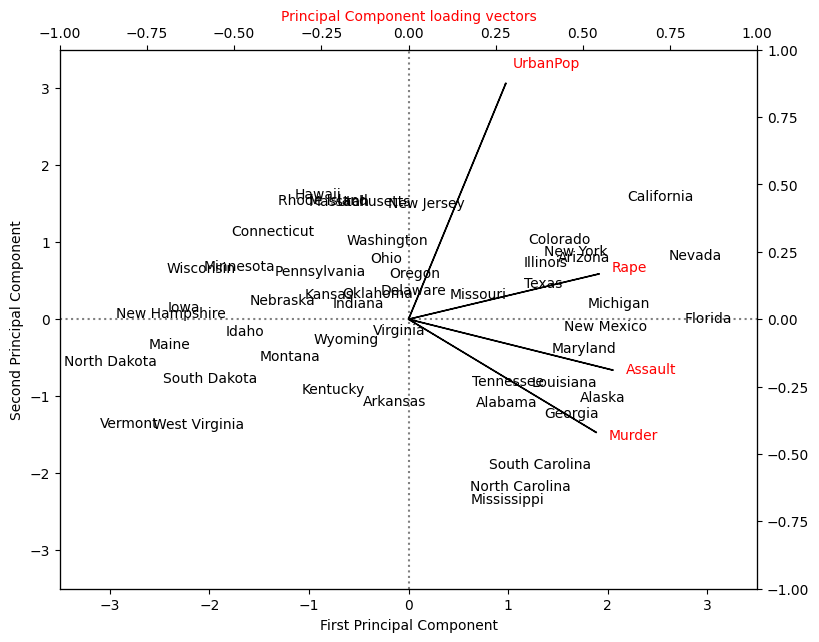

In [71]:
fig , ax1 = plt.subplots(figsize=(9,7))

ax1.set_xlim(-3.5,3.5)
ax1.set_ylim(-3.5,3.5)

# Plot Principal Components 1 and 2
for i in df_plot.index:
    ax1.annotate(i, (df_plot.PC1.loc[i], df_plot.PC2.loc[i]), ha='center')

# Plot reference lines
ax1.hlines(0,-3.5,3.5, linestyles='dotted', colors='grey')
ax1.vlines(0,-3.5,3.5, linestyles='dotted', colors='grey')

ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')
    
# Plot Principal Component loading vectors, using a second y-axis.
ax2 = ax1.twinx().twiny() 

ax2.set_ylim(-1,1)
ax2.set_xlim(-1,1)
ax2.set_xlabel('Principal Component loading vectors', color='red')

# Plot labels for vectors. Variable 'a' is a small offset parameter to separate arrow tip and text.
a = 1.07  
for i in pca_loadings[['V1', 'V2']].index:
    ax2.annotate(i, (pca_loadings.V1.loc[i]*a, pca_loadings.V2.loc[i]*a), color='red')

# Plot vectors
ax2.arrow(0,0,pca_loadings.V1[0], pca_loadings.V2[0])
ax2.arrow(0,0,pca_loadings.V1[1], pca_loadings.V2[1])
ax2.arrow(0,0,pca_loadings.V1[2], pca_loadings.V2[2])
ax2.arrow(0,0,pca_loadings.V1[3], pca_loadings.V2[3])

plt.show()

[0.62006039 0.24744129 0.0891408  0.04335752]


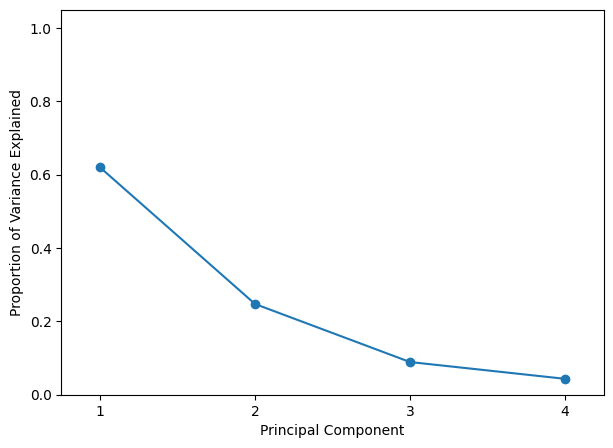

In [73]:
## the proportion of variance explained (PVE)
print(pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot([1,2,3,4], pca.explained_variance_ratio_, '-o')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Component')
plt.xlim(0.75,4.25)
plt.ylim(0,1.05)
plt.xticks([1,2,3,4])
plt.show()

In [76]:
pd.DataFrame([df_plot.iloc[:,:3].std(axis=0, ddof=0).to_numpy(),
              pca.explained_variance_ratio_[:3],
              np.cumsum(pca.explained_variance_ratio_[:3])],
             index=['Standard Deviation',# the scale of the info
                    'Proportion of Variance', 'Cumulative Proportion'],# contribution
             columns=['PC1', 'PC2', 'PC3'])

,PC1,PC2,PC3
Standard Deviation,1.574878,0.994869,0.597129
Proportion of Variance,0.620060,0.247441,0.089141
Cumulative Proportion,0.620060,0.867502,0.956642


# Modeling

## Regression

### Simple linear regression

#### model from numpy ---------------------------------------------------------------------------------------------------------------

In [51]:
adv = pd.read_csv('data/Advertising.csv') 
adv.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


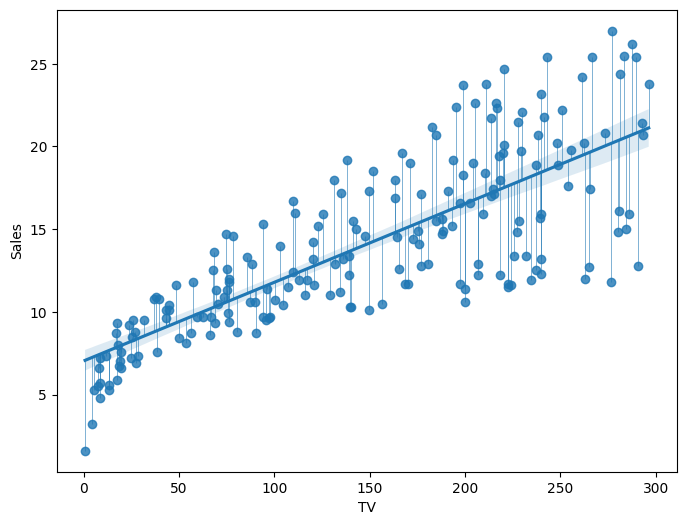

In [52]:
# the regression model from np
fit = np.polyfit(adv['TV'], adv['Sales'], deg=1) # parameter of the model
y_hat = fit[1] + adv['TV'] * fit[0]

plt.figure(figsize=(8, 6))
sns.regplot(x='TV', y='Sales', data=adv)
plt.vlines(adv['TV'], y_hat, adv['Sales'], lw = .4)
plt.show()

#### import statsmodels.formula.api as smf -------------------------------------------------------------------------------------------------------

In [99]:
import statsmodels.formula.api as smf
# credit data
credit=pd.read_csv('data/credit.csv')
credit['Female'] = (credit.Gender == 'Female').astype(int)
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance,Female
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333,0
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903,1
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580,0
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964,1
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331,0


In [100]:
results = smf.ols('Balance ~ Female + Age + Income', data=credit).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     37.71
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.86e-21
Time:                        18:00:04   Log-Likelihood:                -2969.1
No. Observations:                 400   AIC:                             5946.
Df Residuals:                     396   BIC:                             5962.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    346.9171     73.475      4.722      0.000     202.468     491.367
Female        24.7561     40.728      0.608      0.544     -55.315     104.827
Age           -2.1894      1.200     -1.825      0.069      -4.548       0.169
Income         6.2400      0.587     10.626      0.000       5.085       7.395
==============================================================================
Omnibus:                       41.176   Durbin-Watson:                   1.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.051
Skew:                           0.368   Prob(JB):                     4.43e-05
Kurtosis:                       2.186   Cond. No.                         284.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [101]:
# interaction model (if not linear)
results = smf.ols('Sales ~ TV + Radio + TV * Radio', data=adv).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1963.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          6.68e-146
Time:                        18:00:04   Log-Likelihood:                -270.14
No. Observations:                 200   AIC:                             548.3
Df Residuals:                     196   BIC:                             561.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7502      0.248     27.233      0.000       6.261       7.239
TV             0.0191      0.002     12.699      0.000       0.016       0.022
Radio          0.0289      0.009      3.241      0.001       0.011       0.046
TV:Radio       0.0011   5.24e-05     20.727      0.000       0.001       0.001
==============================================================================
Omnibus:                      128.132   Durbin-Watson:                   2.224
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1183.719
Skew:                          -2.323   Prob(JB):                    9.09e-258
Kurtosis:                      13.975   Cond. No.                     1.80e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.8e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [102]:
# power model (if not linear)
results = smf.ols('Sales ~ TV + Radio + np.power(Radio,2)', data=adv).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     573.8
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           9.20e-97
Time:                        18:00:05   Log-Likelihood:                -385.63
No. Observations:                 200   AIC:                             779.3
Df Residuals:                     196   BIC:                             792.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              3.1558      0.369      8.550      0.000       2.428       3.884
TV                     0.0458      0.001     32.926      0.000       0.043       0.049
Radio                  0.1560      0.031      4.969      0.000       0.094       0.218
np.power(Radio, 2)     0.0007      0.001      1.054      0.293      -0.001       0.002
==============================================================================
Omnibus:                       66.663   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              173.446
Skew:                          -1.456   Prob(JB):                     2.17e-38
Kurtosis:                       6.513   Cond. No.                     3.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### check significant of polynomial model------------------------------------------------------------------------------------------------

In [103]:
from statsmodels.stats.anova import anova_lm
anova_lm(results)

,df,sum_sq,mean_sq,F,PR(>F)
TV,1.0,3314.618167,3314.618167,1173.160290,1.140289e-84
Radio,1.0,1545.616603,1545.616603,547.048237,1.265901e-58
"np.power(Radio, 2)",1.0,3.140411,3.140411,1.111502,2.930535e-01
Residual,196.0,553.773569,2.825375,NaN,NaN


### PCR (pca+linearRegression)

In [32]:
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression, PLSSVD
from sklearn.metrics import mean_squared_error


df = pd.read_csv('data/hitters.csv').dropna().drop('Unnamed: 0', axis=1)
y = df.Salary
X = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')
pca = PCA()
X_reduced = pca.fit_transform(scale(X))   ###scale the data
pd.DataFrame(pca.components_.T).loc[:4,:5]

,0,1,2,3,4,5
0,0.196209,0.391118,0.070293,-0.057195,0.104179,-0.269548
1,0.193644,0.383922,0.050152,-0.071087,0.132262,-0.389942
2,0.201534,0.235943,-0.339900,-0.167692,-0.493727,0.238766
3,0.195226,0.381179,-0.063822,-0.126912,0.213325,-0.119529
4,0.232769,0.318169,-0.168631,-0.115430,-0.303608,0.005614


C:\Users\dell\AppData\Local\Temp\ipykernel_25052\2942164367.py:18: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  score = -1*model_selection.cross_val_score(regr, np.ones((n,1)), y_train.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()
C:\Users\dell\AppData\Local\Temp\ipykernel_25052\2942164367.py:23: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  score = -1*model_selection.cross_val_score(regr, X_reduced_train[:,:i], y_train.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()
C:\Users\dell\AppData\Local\Temp\ipykernel_25052\2942164367.py:23: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  score = -1*model_selectio

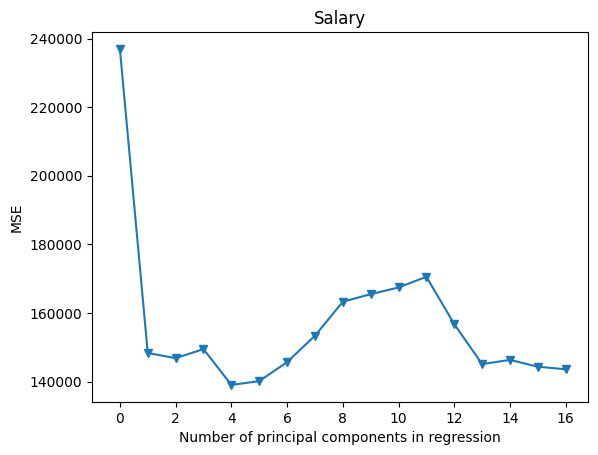

In [33]:
pca2 = PCA()

# Split into training and test sets
X_train, X_test , y_train, y_test = model_selection.train_test_split(X, y, test_size=0.5, random_state=1)

# Scale the data
X_reduced_train = pca2.fit_transform(scale(X_train))
n = len(X_reduced_train)

# 10-fold CV, with shuffle
kf_10 = model_selection.KFold(n_splits=10, shuffle=True, random_state=1)

mse = []
regr = LinearRegression()
mse = []

# Calculate MSE with only the intercept (no principal components in regression)
score = -1*model_selection.cross_val_score(regr, np.ones((n,1)), y_train.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()    
mse.append(score)

# Calculate MSE using CV for the 16 principle components, adding one component at the time.
for i in np.arange(1, 17):
    score = -1*model_selection.cross_val_score(regr, X_reduced_train[:,:i], y_train.ravel(), cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(score)

plt.plot(np.array(mse), '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Salary')
plt.xlim(xmin=-1)
plt.show()

In [35]:
X_reduced_test = pca2.transform(scale(X_test))[:,:5]# the number of feature

# Train regression model on training data 
regr = LinearRegression()
regr.fit(X_reduced_train[:,:5], y_train)

# Prediction with test data
pred = regr.predict(X_reduced_test)
mean_squared_error(y_test, pred)

116602.87131725039

### PLSR

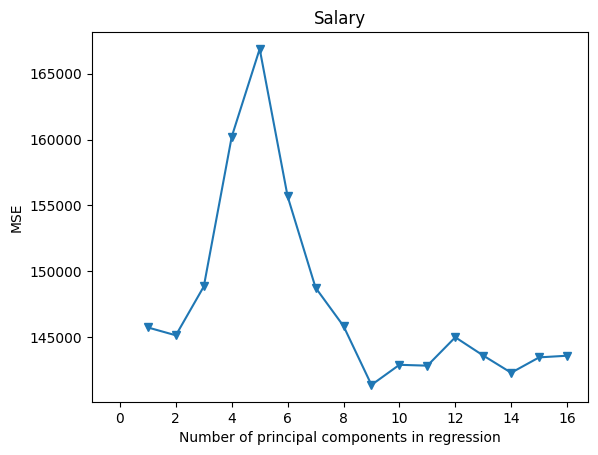

In [26]:
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression, PLSSVD
from sklearn.metrics import mean_squared_error


df = pd.read_csv('data/hitters.csv').dropna().drop('Unnamed: 0', axis=1)
y = df.Salary
X = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')
X_train, X_test , y_train, y_test = model_selection.train_test_split(X, y, test_size=0.5, random_state=1)
n = len(X_train)

# 10-fold CV, with shuffle
kf_10 = model_selection.KFold(n_splits=10, shuffle=True, random_state=1)

mse = []

for i in np.arange(1, 17):
    pls = PLSRegression(n_components=i)
    score = model_selection.cross_val_score(pls, scale(X_train), y_train, cv=kf_10, scoring='neg_mean_squared_error').mean()
    mse.append(-score)

# Plot results
plt.plot(np.arange(1, 17), np.array(mse), '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Salary')
plt.xlim(xmin=-1)
plt.show()

In [27]:
pls = PLSRegression(n_components=9)
pls.fit(scale(X_train), y_train)

mean_squared_error(y_test, pls.predict(scale(X_test)))

112642.02462005438

### Lasso and ridge regression (regularization for overfitting)

In [17]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

df = pd.read_csv('data/hitters.csv').dropna().drop('Unnamed: 0', axis = 1)
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']])
y = df.Salary
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis = 1).astype('float64')
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis = 1)


#### Ridge -------------------------------------------------------------------------------------------------------------------------------

Text(0, 0.5, 'weights')

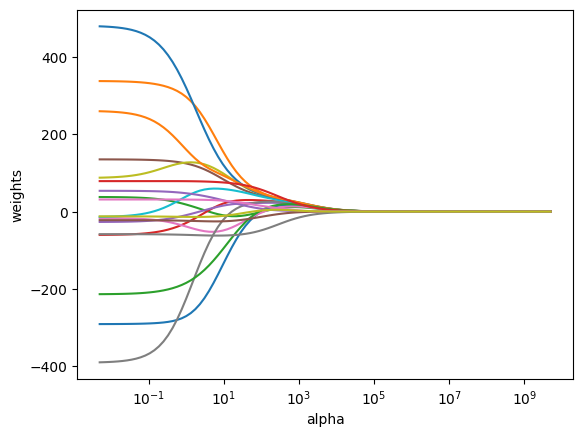

In [18]:
alphas = 10**np.linspace(10,-2,100)*0.5
ridge = Ridge()
coefs = []

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test , y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=1)

for a in alphas:
    ridge.set_params(alpha = a)
    ridge.fit(X_scaled, y)
    coefs.append(ridge.coef_)
    
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')

In [19]:
ridge2 = Ridge(alpha = 4)
ridge2.fit(X_train, y_train)             # Fit a ridge regression on the training data
pred2 = ridge2.predict(X_test)           # Use this model to predict the test data
print(pd.Series(ridge2.coef_, index = X.columns)) # Print coefficients
print(mean_squared_error(y_test, pred2))          # Calculate the test MSE

AtBat         -213.176543
Hits           191.133532
HmRun          -54.236259
Runs             0.497409
RBI             77.755957
Walks           89.751563
Years          -27.347561
CAtBat        -120.436464
CHits           89.341261
CHmRun          83.888337
CRuns           98.317502
CRBI           116.286711
CWalks         -40.517948
PutOuts        117.412662
Assists         26.509603
Errors         -19.132449
League_N        36.016247
Division_W     -60.417909
NewLeague_N    -18.714889
dtype: float64
102375.70769613974


In [20]:
###  use cross-validation to choose the tuning parameter alpha. 
ridgecv = RidgeCV(alphas = alphas, scoring = 'neg_mean_squared_error')
ridgecv.fit(X_train, y_train)
ridgecv.alpha_

np.float64(87.37642000038414)

#### Lasso -------------------------------------------------------------------------------------------------------------------------------

Text(0, 0.5, 'weights')

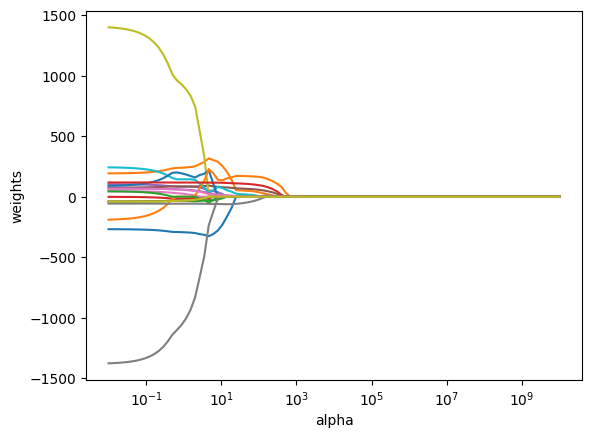

In [21]:
lasso = Lasso(max_iter = 10000)
coefs = []

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test , y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=1)

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)
    
ax = plt.gca()
ax.plot(alphas*2, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')

In [22]:
lassocv = LassoCV(alphas = None, cv = 10, max_iter = 100000)
lassocv.fit(X_train, y_train)

lasso.set_params(alpha=lassocv.alpha_)
lasso.fit(X_train, y_train)
mean_squared_error(y_test, lasso.predict(X_test))

D:\install\anaconda\envs\good\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


105121.06327904538

### Nonlinear regressiion

In [5]:
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm

df = pd.read_csv('data/wage.csv')
# Generate a sequence of age values spanning the range
age_grid = np.arange(df.age.min(), df.age.max()).reshape(-1,1)

#### Polynomial ------------------------------------------------------------------------------------------------------------------------------

In [36]:
X1 = PolynomialFeatures(1).fit_transform(df.age.values.reshape(-1,1))
X2 = PolynomialFeatures(2).fit_transform(df.age.values.reshape(-1,1))
X3 = PolynomialFeatures(3).fit_transform(df.age.values.reshape(-1,1))
X4 = PolynomialFeatures(4).fit_transform(df.age.values.reshape(-1,1))
X5 = PolynomialFeatures(5).fit_transform(df.age.values.reshape(-1,1))
fit2 = sm.GLS(df.wage, X4).fit()
fit2.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,-184.1542,60.040,-3.067,0.002,-301.879,-66.430
x1,21.2455,5.887,3.609,0.000,9.703,32.788
x2,-0.5639,0.206,-2.736,0.006,-0.968,-0.160
x3,0.0068,0.003,2.221,0.026,0.001,0.013
x4,-3.204e-05,1.64e-05,-1.952,0.051,-6.42e-05,1.45e-07


In [37]:
fit_1 = fit = sm.GLS(df.wage, X1).fit()
fit_2 = fit = sm.GLS(df.wage, X2).fit()
fit_3 = fit = sm.GLS(df.wage, X3).fit()
fit_4 = fit = sm.GLS(df.wage, X4).fit()
fit_5 = fit = sm.GLS(df.wage, X5).fit()

print(sm.stats.anova_lm(fit_1, fit_2, fit_3, fit_4, fit_5, typ=1))

   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


D:\install\anaconda\envs\good\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


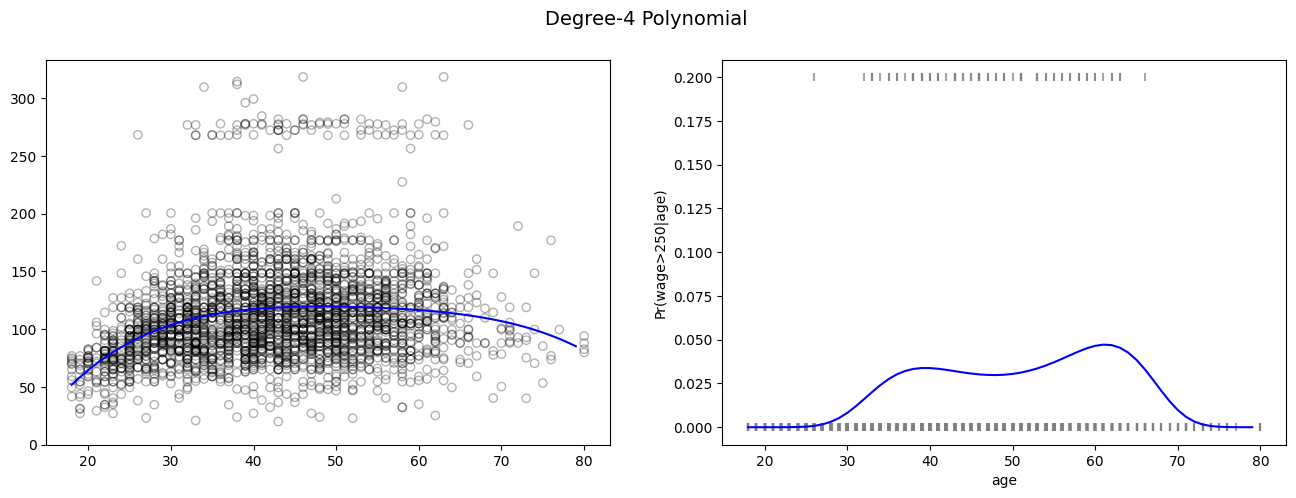

In [41]:
# Create response matrix
y = (df.wage > 250).map({False:0, True:1}).to_numpy()

# Fit logistic model
clf = sm.GLM(y, X4, family=sm.families.Binomial(sm.families.links.logit()))
res = clf.fit()

# Generate a sequence of age values spanning the range
age_grid = np.arange(df.age.min(), df.age.max()).reshape(-1,1)

# Generate test data
X_test = PolynomialFeatures(4).fit_transform(age_grid)

# Predict the value of the generated ages
pred1 = fit2.predict(X_test) # salary
pred2 = res.predict(X_test)  # Pr(wage>250)

# creating plots
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (16,5))
fig.suptitle('Degree-4 Polynomial', fontsize=14)

# Scatter plot with polynomial regression line
ax1.scatter(df.age, df.wage, facecolor='None', edgecolor='k', alpha=0.3)
ax1.plot(age_grid, pred1, color = 'b')
ax1.set_ylim(ymin=0)

# Logistic regression showing Pr(wage>250) for the age range.
ax2.plot(age_grid, pred2, color='b')

# Rug plot showing the distribution of wage>250 in the training data.
# 'True' on the top, 'False' on the bottom.
ax2.scatter(df.age, y/5, s=30, c='grey', marker='|', alpha=0.7)

ax2.set_ylim(-0.01,0.21)
ax2.set_xlabel('age')
ax2.set_ylabel('Pr(wage>250|age)')
plt.show()

#### Piecewise -----------------------------------------------------------------------------------------------------------------------------

In [39]:
df_cut, bins = pd.cut(df.age, 4, retbins = True, right = True)
df_cut.value_counts(sort = False)
df_steps = pd.concat([df.age, df_cut, df.wage], keys = ['age','age_cuts','wage'], axis = 1)

# Create dummy variables for the age groups
df_steps_dummies = pd.get_dummies(df_steps['age_cuts'])

# Statsmodels requires explicit adding of a constant (intercept)
df_steps_dummies = sm.add_constant(df_steps_dummies)

# Drop the (17.938, 33.5] category
df_steps_dummies = df_steps_dummies.drop(df_steps_dummies.columns[1], axis = 1)

df_steps_dummies.head(5)

,const,"(33.5, 49.0]","(49.0, 64.5]","(64.5, 80.0]"
0,1.0,False,False,False
1,1.0,False,False,False
2,1.0,True,False,False
3,1.0,True,False,False
4,1.0,False,True,False


In [40]:
fit3 = sm.GLM(df_steps.wage.to_numpy(), df_steps_dummies.astype(int).to_numpy()).fit()
fit3.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
const,94.1584,1.476,63.790,0.000,91.265,97.051
x1,24.0535,1.829,13.148,0.000,20.468,27.639
x2,23.6646,2.068,11.443,0.000,19.611,27.718
x3,7.6406,4.987,1.532,0.126,-2.135,17.416


D:\install\anaconda\envs\good\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


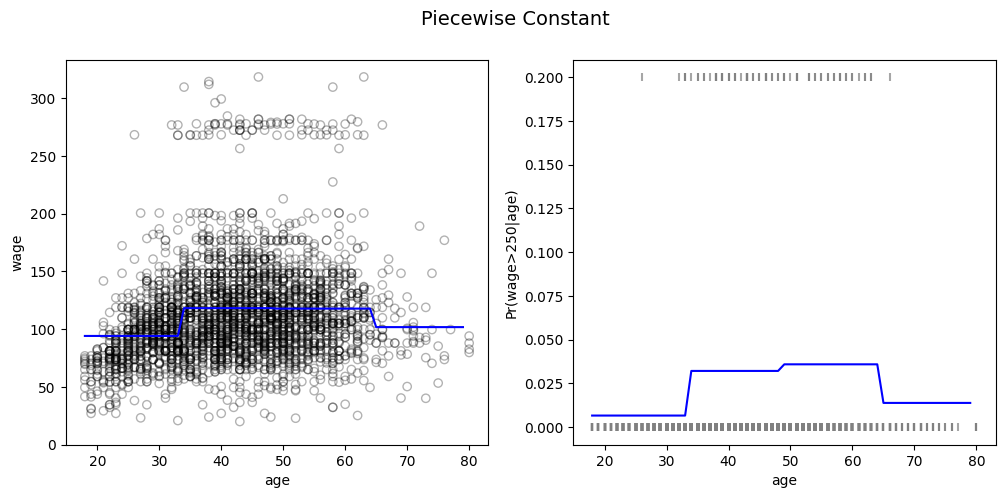

In [42]:
# Put the test data in the same bins as the training data.
bin_mapping = np.digitize(age_grid.ravel(), bins)

# Get dummies, drop first dummy category, add constant
X_test2 = sm.add_constant(pd.get_dummies(bin_mapping).drop(1, axis = 1)).astype(int).to_numpy()

# Predict the value of the generated ages using the linear model
pred2 = fit3.predict(X_test2)

# And the logistic model
clf2 = sm.GLM(y, df_steps_dummies.astype(int).to_numpy(),
              family=sm.families.Binomial(sm.families.links.logit()))
res2 = clf2.fit()
pred3 = res2.predict(X_test2)

# Plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))
fig.suptitle('Piecewise Constant', fontsize = 14)

# Scatter plot with polynomial regression line
ax1.scatter(df.age, df.wage, facecolor = 'None', edgecolor = 'k', alpha = 0.3)
ax1.plot(age_grid, pred2, c = 'b')

ax1.set_xlabel('age')
ax1.set_ylabel('wage')
ax1.set_ylim(ymin = 0)

# Logistic regression showing Pr(wage>250) for the age range.
ax2.plot(np.arange(df.age.min(), df.age.max()).reshape(-1,1), pred3, color = 'b')

# Rug plot showing the distribution of wage>250 in the training data.
# 'True' on the top, 'False' on the bottom.
ax2.scatter(df.age, y/5, s = 30, c = 'grey', marker = '|', alpha = 0.7)

ax2.set_ylim(-0.01, 0.21)
ax2.set_xlabel('age')
ax2.set_ylabel('Pr(wage>250|age)')
plt.show()

#### Splines --------------------------------------------------------------------------------------------------------------------------------

In [6]:
from patsy import dmatrix

# Specifying 3 knots
transformed_x1 = dmatrix("bs(df.age, knots=(25,40,60), degree=3, include_intercept=False)",
                        {"df.age": df.age}, return_type='dataframe') 
#knots=(25,40,60)：在年龄 25、40、60 处设定结点（knots），允许函数在这些点发生弯折。
#degree=3：三次样条（cubic spline）。include_intercept=False：不包含截距列。

transformed_x2 = dmatrix(
    "bs(df.age, df=6, include_intercept=False)",
    {"df.age": df.age}, return_type='dataframe')
#df=6：指定自由度为 6，自动选择结点位置。

transformed_x3 = dmatrix(
    "cr(df.age, df=4)",
    {"df.age": df.age}, return_type='dataframe')
#cr = cubic regression spline（自然样条）; df=4：自由度为 4。

# Build a regular linear model from the splines
fit1 = sm.GLM(df.wage, transformed_x1).fit()
fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                   wage   No. Observations:                 3000
Model:                            GLM   Df Residuals:                     2993
Model Family:                Gaussian   Df Model:                            6
Link Function:               Identity   Scale:                          1594.0
Method:                          IRLS   Log-Likelihood:                -15314.
Date:                Wed, 01 Jul 2026   Deviance:                   4.7708e+06
Time:                        10:17:50   Pearson chi2:                 4.77e+06
No. Iterations:                     3   Pseudo R-squ. (CS):            0.09006
Covariance Type:            nonrobust                                         
========================================================================================================================================
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               60.4937      9.460      6.394      0.000      41.952      79.036
bs(df.age, knots=(25, 40, 60), degree=3, include_intercept=False)[0]     3.9805     12.538      0.317      0.751     -20.593      28.554
bs(df.age, knots=(25, 40, 60), degree=3, include_intercept=False)[1]    44.6310      9.626      4.636      0.000      25.764      63.498
bs(df.age, knots=(25, 40, 60), degree=3, include_intercept=False)[2]    62.8388     10.755      5.843      0.000      41.759      83.919
bs(df.age, knots=(25, 40, 60), degree=3, include_intercept=False)[3]    55.9908     10.706      5.230      0.000      35.007      76.975
bs(df.age, knots=(25, 40, 60), degree=3, include_intercept=False)[4]    50.6881     14.402      3.520      0.000      22.461      78.915
bs(df.age, knots=(25, 40, 60), degree=3, include_intercept=False)[5]    16.6061     19.126      0.868      0.385     -20.881      54.093
========================================================================================================================================
"""

### Decision tree

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
boston_df = pd.read_csv('data/boston.csv')
X = boston_df.drop('medv', axis = 1)
y = boston_df.medv
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 0)

# Pruning not supported. Choosing max depth 2)
regr_tree_boston = DecisionTreeRegressor(max_depth = 2)
regr_tree_boston.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
import graphviz
export_graphviz(regr_tree_boston, 
                out_file = "boston_tree.dot", 
                feature_names = X_train.columns)

with open("boston_tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

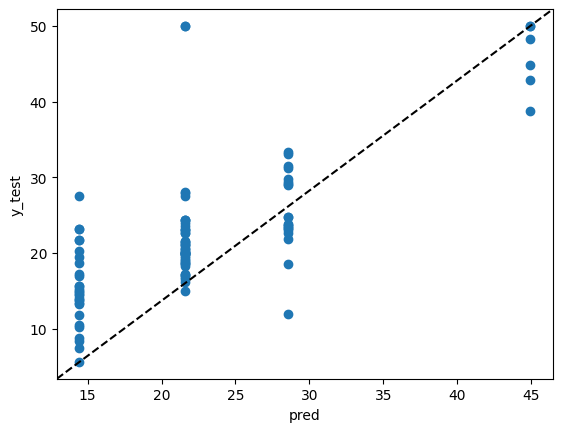

35.40621582879024

In [53]:
pred = regr_tree_boston.predict(X_test)

plt.scatter(pred, 
            y_test, 
            label = 'medv')

plt.plot([0, 1], 
         [0, 1], 
         '--k', 
         transform = plt.gca().transAxes)

plt.xlabel('pred')
plt.ylabel('y_test')
plt.show()

mean_squared_error(y_test, pred)

### Random forest

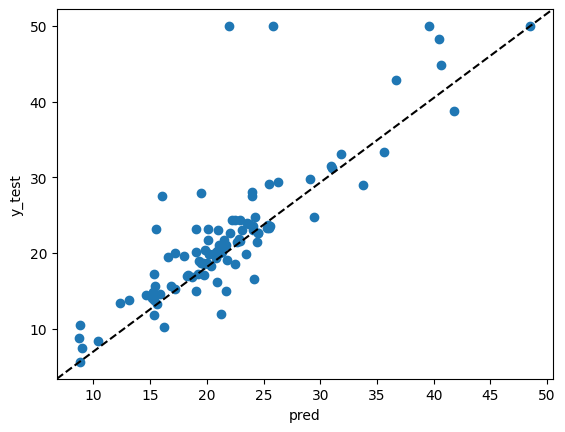

24.128542431372562

In [10]:
# Bagging: using all features
bagged_boston = RandomForestRegressor(max_features = 4, random_state = 2)
bagged_boston.fit(X_train, y_train)

pred = bagged_boston.predict(X_test)

plt.scatter(pred, 
            y_test, 
            label = 'medv')

plt.plot([0, 1], 
         [0, 1], 
         '--k', 
         transform = plt.gca().transAxes)

plt.xlabel('pred')
plt.ylabel('y_test')
plt.show()

mean_squared_error(y_test, pred)

In [11]:
# Random forests: using 6 features
random_forest_boston = RandomForestRegressor(max_features = 6, random_state = 2)

random_forest_boston.fit(X_train, y_train)

pred = random_forest_boston.predict(X_test)
mean_squared_error(y_test, pred)

20.22936232352941

In [56]:
random_forest_boston.feature_importances_
# view the importance of each variable:

array([0.06089887, 0.00849057, 0.06617231, 0.0041641 , 0.06473178,
       0.2752692 , 0.02734713, 0.05162853, 0.00825491, 0.02697549,
       0.10518757, 0.01814718, 0.28273236])

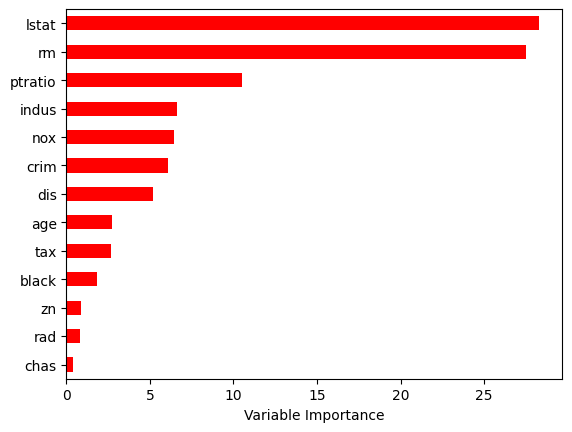

In [57]:
Importance = pd.DataFrame({'Importance':random_forest_boston.feature_importances_*100}, 
                          index = X.columns)

Importance.sort_values(by = 'Importance', 
                       axis = 0, 
                       ascending = True).plot(kind = 'barh', 
                                              color = 'r', )

plt.xlabel('Variable Importance')
plt.gca().legend_ = None
plt.show()

### Boost

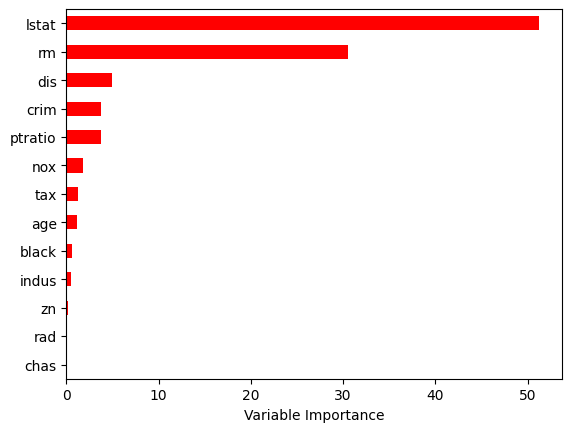

In [58]:
boosted_boston = GradientBoostingRegressor(n_estimators = 500, # how many trees
                                           learning_rate = 0.01, # conbribution of the new tree
                                           max_depth = 4, # how deep
                                           random_state = 1)# random state

boosted_boston.fit(X_train, y_train)

## Let's check out the feature importances again:
feature_importance = boosted_boston.feature_importances_*100

rel_imp = pd.Series(feature_importance, 
                    index = X.columns).sort_values(inplace = False)

rel_imp.T.plot(kind = 'barh', 
               color = 'r', )

plt.xlabel('Variable Importance')

plt.gca().legend_ = None
plt.show()

## Classification

### Logistic regression

#### import statsmodels.formula.api as smf -----------------------------------------------------------------------------------------------------

In [123]:
import statsmodels.formula.api as smf
default = pd.read_csv("data/default.csv")
default['Yes'] = (default['default'] == 'Yes').astype(int)
default.head()

,default,student,balance,income,Yes
0,No,No,729.526495,44361.625074,0
1,No,Yes,817.180407,12106.134700,0
2,No,No,1073.549164,31767.138947,0
3,No,No,529.250605,35704.493935,0
4,No,No,785.655883,38463.495879,0


In [65]:
# for 1 predictor
result = smf.logit('Yes ~ balance', data=default).fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    Yes   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                  0.4534
Time:                        16:31:10   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.6513      0.361    -29.491      0.000     -11.359      -9.943
balance        0.0055      0.000     24.952      0.000       0.005       0.006
==============================================================================

Possibly complete quasi-separation: A fraction 0.13 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

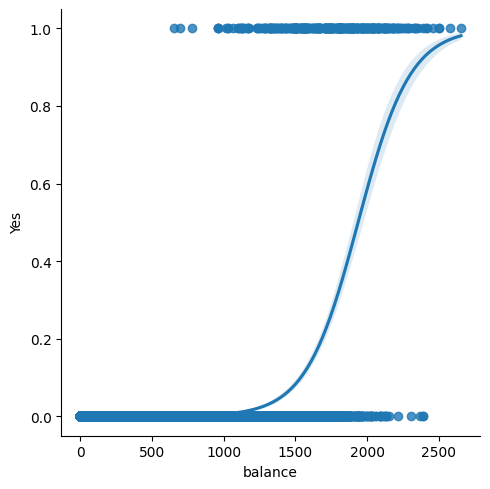

In [66]:
sns.lmplot(x='balance', y='Yes', data=default, logistic=True)
plt.show()

In [68]:
# for more predictors
results = smf.logit('Yes ~ balance + student', data=default).fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.078584
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    Yes   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                  0.4619
Time:                        16:38:19   Log-Likelihood:                -785.84
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                1.189e-293
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -10.7495      0.369    -29.115      0.000     -11.473     -10.026
student[T.Yes]    -0.7149      0.148     -4.846      0.000      -1.004      -0.426
balance            0.0057      0.000     24.748      0.000       0.005       0.006
==================================================================================

Possibly complete quasi-separation: A fraction 0.15 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

#### from sklearn.linear_model import LogisticRegression ------------------------------------------------------------------------------------

In [67]:
# for 1 predictor
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
X = np.column_stack((np.ones(len(default)), default['balance'])) # predictor variable
lr.fit(X, default['Yes']) # predictor and respond variable
print('Model coefficients are: ',lr.coef_)
print('Predict when preditor variable equals to 1000: ',lr.predict_proba([[1, 1000]]))

Model coefficients are:  [[0.0017222  0.00549912]]
Predict when preditor variable equals to 1000:  [[0.99424861 0.00575139]]


In [70]:
# for 2 predictors
default['student_yes'] = (default['student'] == 'Yes').astype(int)
X = np.column_stack((np.ones(len(default)), default['balance'], default['student_yes']))
lr.fit(X, default['Yes'])
print('Model coefficients are: ',lr.coef_)
print('Predict when preditor variable equals to 1000: ',lr.predict_proba([[1, 1000,1]]))

Model coefficients are:  [[-1.80190793e-06  5.73175442e-03 -6.99678108e-01]]
Predict when preditor variable equals to 1000:  [[0.99670704 0.00329296]]


#### simpsons paradox: the direction of predictor variables may change in the polynomial model.

### Linear Discriminant Analysis (LDA)

In [75]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
default = pd.read_csv("data/default.csv")
lda=LinearDiscriminantAnalysis()
default['Yes'] = (default['default'] == 'Yes').astype(int)
default['St'] = (default['student'] == 'Yes').astype(int)
X=default[['St', 'balance']].values
y=default['Yes'].values
lda.fit(X,y)


from sklearn.metrics import confusion_matrix
con=confusion_matrix(y, lda.predict(X))
print('Confusion matrix: ')
print(con)
print('Prediction: ',lda.predict([[-0.8, -1]]))

Confusion matrix: 
[[9644   23]
 [ 252   81]]
Prediction:  [0]


In [81]:
#Get predicted probabilities for class 1
probs = lda.predict_proba(X)[:, 1]
print('The probabilities for class 1 in first 3 element: ',probs[:3])

#Manually apply a custom threshold
threshold = 0.3  # you can change this to 0.5, 0.7, etc.
## set the probability for class 1 equals to 0.3.
y_pred_custom = (probs >= threshold).astype(int)

# 5. Evaluate
print("Confusion Matrix (threshold=0.3):")
print(confusion_matrix(y, y_pred_custom))

The probabilities for class 1 in first 3 element:  [0.00313198 0.00280753 0.01560305]
Confusion Matrix (threshold=0.3):
[[9570   97]
 [ 182  151]]


In [82]:
#You can also change the prior probability
lda2 = LinearDiscriminantAnalysis(priors=[0.9,0.1])
lda2.fit(X,y)
print("Confusion Matrix (priors=[0.9,0.1]):")
print(confusion_matrix(y,lda2.predict(X)))

Confusion Matrix (priors=[0.9,0.1]):
[[9496  171]
 [ 156  177]]


### Quadratic Discriminant Analysis (QDA)

In [87]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
smarket = pd.read_csv('data/smarket.csv')
smarket['Up'] = np.where(smarket['Direction'] == 'Up', 1, 0)
smarket.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction,Up
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up,1
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up,1
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down,0
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up,1
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up,1


In [86]:
smarket.drop(columns='Direction').corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Up
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095,0.074608
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155,-0.039757
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250,-0.024081
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448,0.006132
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900,0.004215
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860,0.005423
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592,0.022951
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000,0.730563
Up,0.074608,-0.039757,-0.024081,0.006132,0.004215,0.005423,0.022951,0.730563,1.000000


In [92]:
X = smarket[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']].values
y = smarket['Up'].values
train_bool = smarket['Year'].values < 2005
X_train = X[train_bool]
X_test = X[~train_bool]
y_train = y[train_bool]
y_test = y[~train_bool]

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train[:,:2], y_train)
print('Confusion matrix:')
print(confusion_matrix(y_test, qda.predict(X_test[:,:2])))
print('Prediction: ',qda.predict([[-0.8, -1]]))

Confusion matrix:
[[ 30  81]
 [ 20 121]]
Prediction:  [1]


### K-Nearest Neighbors (KNN)

In [95]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3) # base on how many neighbor?
knn.fit(X_train[:,:2], y_train)
print('Confusion matrix:')
print(confusion_matrix(y_test, knn.predict(X_test[:,:2])))
print('Prediction: ',knn.predict([[-0.8, -1]]))

Confusion matrix:
[[48 63]
 [55 86]]
Prediction:  [1]


### Decision tree

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
import graphviz

df3 = pd.read_csv('data/carseats.csv')
df3['High'] = df3.Sales.map(lambda x: 1 if x>8 else 0)
df3.ShelveLoc = pd.factorize(df3.ShelveLoc)[0]
df3.Urban = df3.Urban.map({'No':0, 'Yes':1})
df3.US = df3.US.map({'No':0, 'Yes':1})
X = df3.drop(['Sales', 'High'], axis = 1)
y = df3.High

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 0)

classification_tree_carseats = DecisionTreeClassifier(max_depth = 6)
classification_tree_carseats.fit(X_train, y_train)
classification_tree_carseats.score(X_train, y_train)

0.921875

In [ ]:
export_graphviz(classification_tree_carseats, 
                out_file = "carseat_tree.dot", 
                feature_names = X_train.columns)

with open("carseat_tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [51]:
pred = classification_tree_carseats.predict(X_test)
cm = pd.DataFrame(confusion_matrix(y_test, pred).T, 
                  index = ['No', 'Yes'], 
                  columns = ['No', 'Yes'])
print(cm)
# (36+22)/80 = 0.745

     No  Yes
No   36   15
Yes   7   22


### SVM

In [63]:
import matplotlib as mpl
# We'll define a function to draw a nice plot of an SVM
def plot_svc(svc, X, y, h=0.02, pad=0.25):
    x_min, x_max = X[:, 0].min()-pad, X[:, 0].max()+pad
    y_min, y_max = X[:, 1].min()-pad, X[:, 1].max()+pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.2)

    plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=mpl.cm.Paired)
    # Support vectors indicated in plot by vertical lines
    sv = svc.support_vectors_
    plt.scatter(sv[:,0], sv[:,1], c='k', marker='x', s=100, linewidths=1)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()
    print('Number of support vectors: ', svc.support_.size)

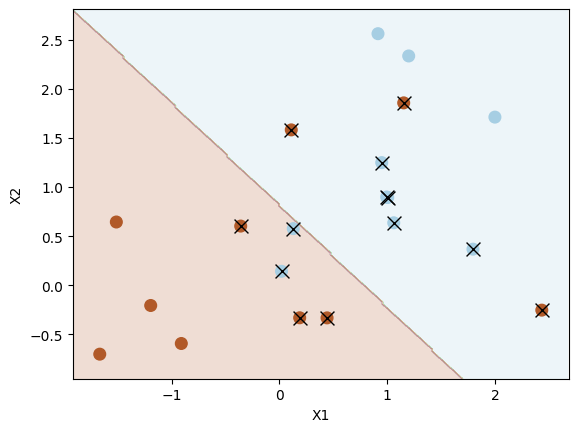

Number of support vectors:  13


In [64]:
from sklearn.svm import SVC
np.random.seed(5)
X = np.random.randn(20,2)
y = np.repeat([1,-1], 10)
X[y == -1] = X[y == -1]+1

svc = SVC(C=1,# limitation
          kernel='linear')# for linear. rbf, poly for nonlinearb
# svm = SVC(C=1.0, kernel='rbf', gamma=1)
# more gamma means more fitting

svc.fit(X, y)
plot_svc(svc, X, y)

In [65]:
# Perform 10-fold cross-validation to compare SVCs with a linear kernel, using a range of values of the cost parameter:
from sklearn.model_selection import GridSearchCV

# Select the optimal C parameter by cross-validation
tuned_parameters = [{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy')
clf.fit(X, y)

,estimator,SVC(kernel='linear')
,param_grid,"[{'C': [0.001, 0.01, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.001


### more fancy confusion matrix and roc

In [115]:
from sklearn.model_selection import cross_val_predict
df2 = pd.read_csv('data/default.csv', na_values='?').dropna()
df2['Yes'] = (df2['default'] == 'Yes').astype(int)
X = np.column_stack((np.ones(len(df2)), df2['balance']))
y=df2['Yes'].values

lr=LogisticRegression()
predicted = cross_val_predict(lr, X, y, cv=5)


from sklearn.metrics import classification_report
print('Confusion matrix report:')
print(classification_report(y,predicted))

from sklearn import metrics
print(metrics.accuracy_score(y, predicted))
print(metrics.classification_report(y,predicted))

Confusion matrix report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9667
           1       0.70      0.30      0.42       333

    accuracy                           0.97     10000
   macro avg       0.84      0.65      0.70     10000
weighted avg       0.97      0.97      0.97     10000

0.9725
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9667
           1       0.70      0.30      0.42       333

    accuracy                           0.97     10000
   macro avg       0.84      0.65      0.70     10000
weighted avg       0.97      0.97      0.97     10000



**Precision Score:**
The precision is intuitively the ability of the classifier not to label as positive a sample that is negative. TP – True Positives FP – False Positives

Precision – Accuracy of positive predictions. Precision = TP/(TP + FP)

**Recall Score:**
The recall is intuitively the ability of the classifier to find all the positive samples. FN – False Negatives

Recall (aka sensitivity or true positive rate): Fraction of positives That were correctly identified. Recall = TP/(TP+FN)

**F1 Score:**
F1 Score (aka F-Score or F-Measure) – A helpful metric for comparing two classifiers. F1 Score takes into account precision and the recall. It is created by finding the the harmonic mean of precision and recall.

F1 = 2 x (precision x recall)/(precision + recall)

*The F1 score reaches its best value at 1 and worst score at 0.*

*The F1 score weights recall more than precision by a factor of beta. beta == 1.0 means recall and precision are equally important.*

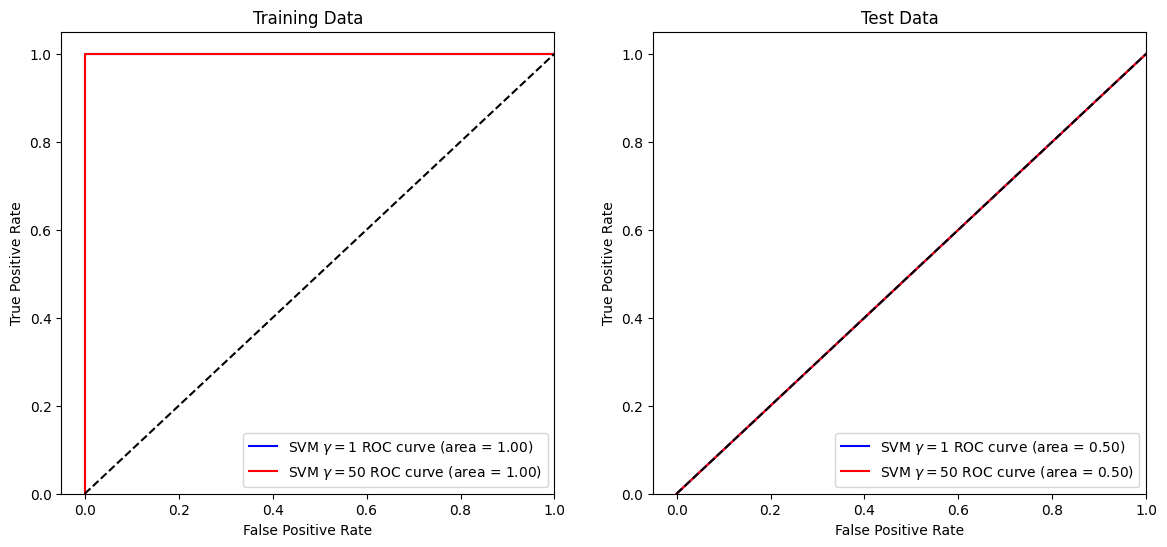

In [69]:
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

# More constrained model
svm3 = SVC(C=1, kernel='rbf', gamma=1)
svm3.fit(X_train, y_train)
# More flexible model
svm4 = SVC(C=1, kernel='rbf', gamma=50)
svm4.fit(X_train, y_train)

y_train_score3 = svm3.decision_function(X_train)
y_train_score4 = svm4.decision_function(X_train)

false_pos_rate3, true_pos_rate3, _ = roc_curve(y_train, y_train_score3)
roc_auc3 = auc(false_pos_rate3, true_pos_rate3)

false_pos_rate4, true_pos_rate4, _ = roc_curve(y_train, y_train_score4)
roc_auc4 = auc(false_pos_rate4, true_pos_rate4)

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14,6))
ax1.plot(false_pos_rate3, true_pos_rate3, label='SVM $\gamma = 1$ ROC curve (area = %0.2f)' % roc_auc3, color='b')
ax1.plot(false_pos_rate4, true_pos_rate4, label='SVM $\gamma = 50$ ROC curve (area = %0.2f)' % roc_auc4, color='r')
ax1.set_title('Training Data')

y_test_score3 = svm3.decision_function(X_test)
y_test_score4 = svm4.decision_function(X_test)

false_pos_rate3, true_pos_rate3, _ = roc_curve(y_test, y_test_score3)
roc_auc3 = auc(false_pos_rate3, true_pos_rate3)

false_pos_rate4, true_pos_rate4, _ = roc_curve(y_test, y_test_score4)
roc_auc4 = auc(false_pos_rate4, true_pos_rate4)

ax2.plot(false_pos_rate3, true_pos_rate3, label='SVM $\gamma = 1$ ROC curve (area = %0.2f)' % roc_auc3, color='b')
ax2.plot(false_pos_rate4, true_pos_rate4, label='SVM $\gamma = 50$ ROC curve (area = %0.2f)' % roc_auc4, color='r')
ax2.set_title('Test Data')

for ax in fig.axes:
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([-0.05, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right")

plt.show()

## Clustering

### Kmeans (the main dot is calculated by mean)

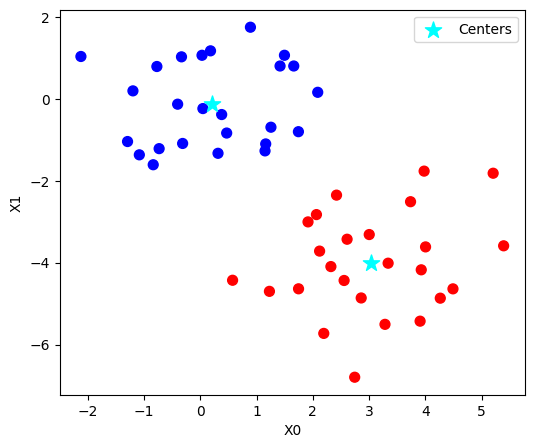

In [77]:
np.random.seed(123)
X = np.random.randn(50,2)
X[0:25, 0] = X[0:25, 0] + 3
X[0:25, 1] = X[0:25, 1] - 4

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3,# clustering in 3
                n_init = 1,# loop once
                random_state = 123).fit(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s = 50, c = kmeans.labels_, cmap = plt.cm.bwr) 
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1], 
            marker = '*', 
            s = 150,
            color = 'cyan', 
            label = 'Centers')
plt.legend(loc = 'best')
plt.xlabel('X0')
plt.ylabel('X1')

plt.show()

### Kmodes (the main dot picked by mode)

In [79]:
from kmodes.kmodes import KModes

# random categorical data
data = np.random.choice(20, (100, 10))
km = KModes(n_clusters=4, # clustering in 4
            init='Huang',
            n_init=5,# loop 5 times
            verbose=1)# print the processing, 0 means turn off

clusters = km.fit_predict(data)
print(km.cluster_centroids_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 18, cost: 799.0
Run 1, iteration: 2/100, moves: 6, cost: 798.0
Run 1, iteration: 3/100, moves: 0, cost: 798.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 13, cost: 807.0
Run 2, iteration: 2/100, moves: 2, cost: 807.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 19, cost: 803.0
Run 3, iteration: 2/100, moves: 6, cost: 802.0
Run 3, iteration: 3/100, moves: 0, cost: 802.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 18, cost: 798.0
Run 4, iteration: 2/100, moves: 4, cost: 798.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 24, cost: 792.0
Run 5, iteration: 2/100, moves: 2, cost: 792.0
Best run was number 5
[[14 14 1

### Kmedoids (the main dot is a real sample)

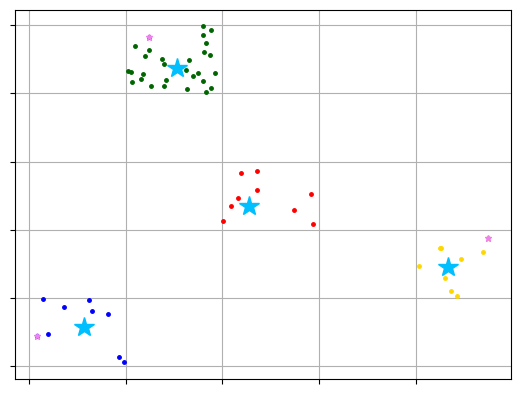

In [13]:
from pyclustering.samples.definitions import SIMPLE_SAMPLES
from pyclustering.cluster import cluster_visualizer
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import read_sample

import numpy, warnings 
numpy.warnings = warnings

# load list of points for cluster analysis
sample = read_sample(SIMPLE_SAMPLES.SAMPLE_SIMPLE3)

# initialize
initial_medoids = kmeans_plusplus_initializer(sample, 4, # 4 dots with more distance
                                              kmeans_plusplus_initializer.FARTHEST_CENTER_CANDIDATE).initialize(return_index=True)

# create instance of K-Medoids algorithm
kmedoids_instance = kmedoids(sample, 
                             initial_medoids)# the index of dots picked

# run cluster analysis and obtain results
kmedoids_instance.process()
clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

# visualize clustering results
visualizer = cluster_visualizer(1)
visualizer.append_clusters(clusters, sample, 0)
visualizer.append_cluster([sample[index] for index in initial_medoids], marker='*', markersize=5)
visualizer.append_cluster(medoids, data=sample, marker='*', markersize=15)
visualizer.show();

### Kprototype (the dots base on both)

In [80]:
from kmodes.kprototypes import KPrototypes
operating_systems = ["Android","iOS"]
isp_names = ["Cox","HughesNet","Xfinity","AT&T"]

data = []
for i in range(100):
    row = []
    row.append(np.random.choice(operating_systems)) #OS
    row.append(np.random.choice(isp_names)) #ISP
    row.append(np.random.poisson(lam=25)) #Age 
    row.append(np.random.uniform(low=0.5, high=1000)) #Time Spent
    data.append(row)

customers = pd.DataFrame(data, columns = ['OS', 'ISP','Age','Time Spent'])
from sklearn import preprocessing
customers_norm = customers.copy()
scaler = preprocessing.MinMaxScaler()
customers_norm[['Age','Time Spent']] = scaler.fit_transform(customers_norm[['Age','Time Spent']])

kproto = KPrototypes(n_clusters=3,# clustering in 3
                     init='Cao')

# specify which columns in the data are categorical (columns 0 and 1)
clusters = kproto.fit_predict(customers_norm, categorical=[0, 1])
#join data with labels 
labels = pd.DataFrame(clusters)
labeledCustomers = pd.concat((customers,labels),axis=1)
labeledCustomers = labeledCustomers.rename({0:'labels'},axis=1)

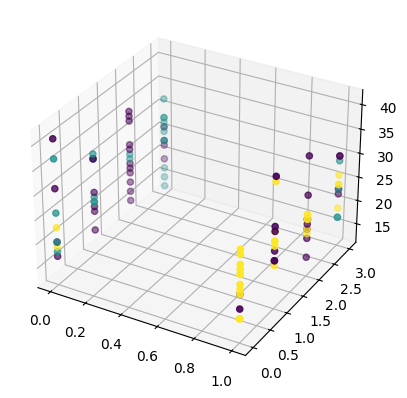

In [81]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")


ax.scatter(labeledCustomers.OS.astype('category').cat.codes, labeledCustomers.ISP.astype('category').cat.codes, 
           labeledCustomers.Age, c = labeledCustomers.labels) 

plt.show()

### Hierarchical clustering

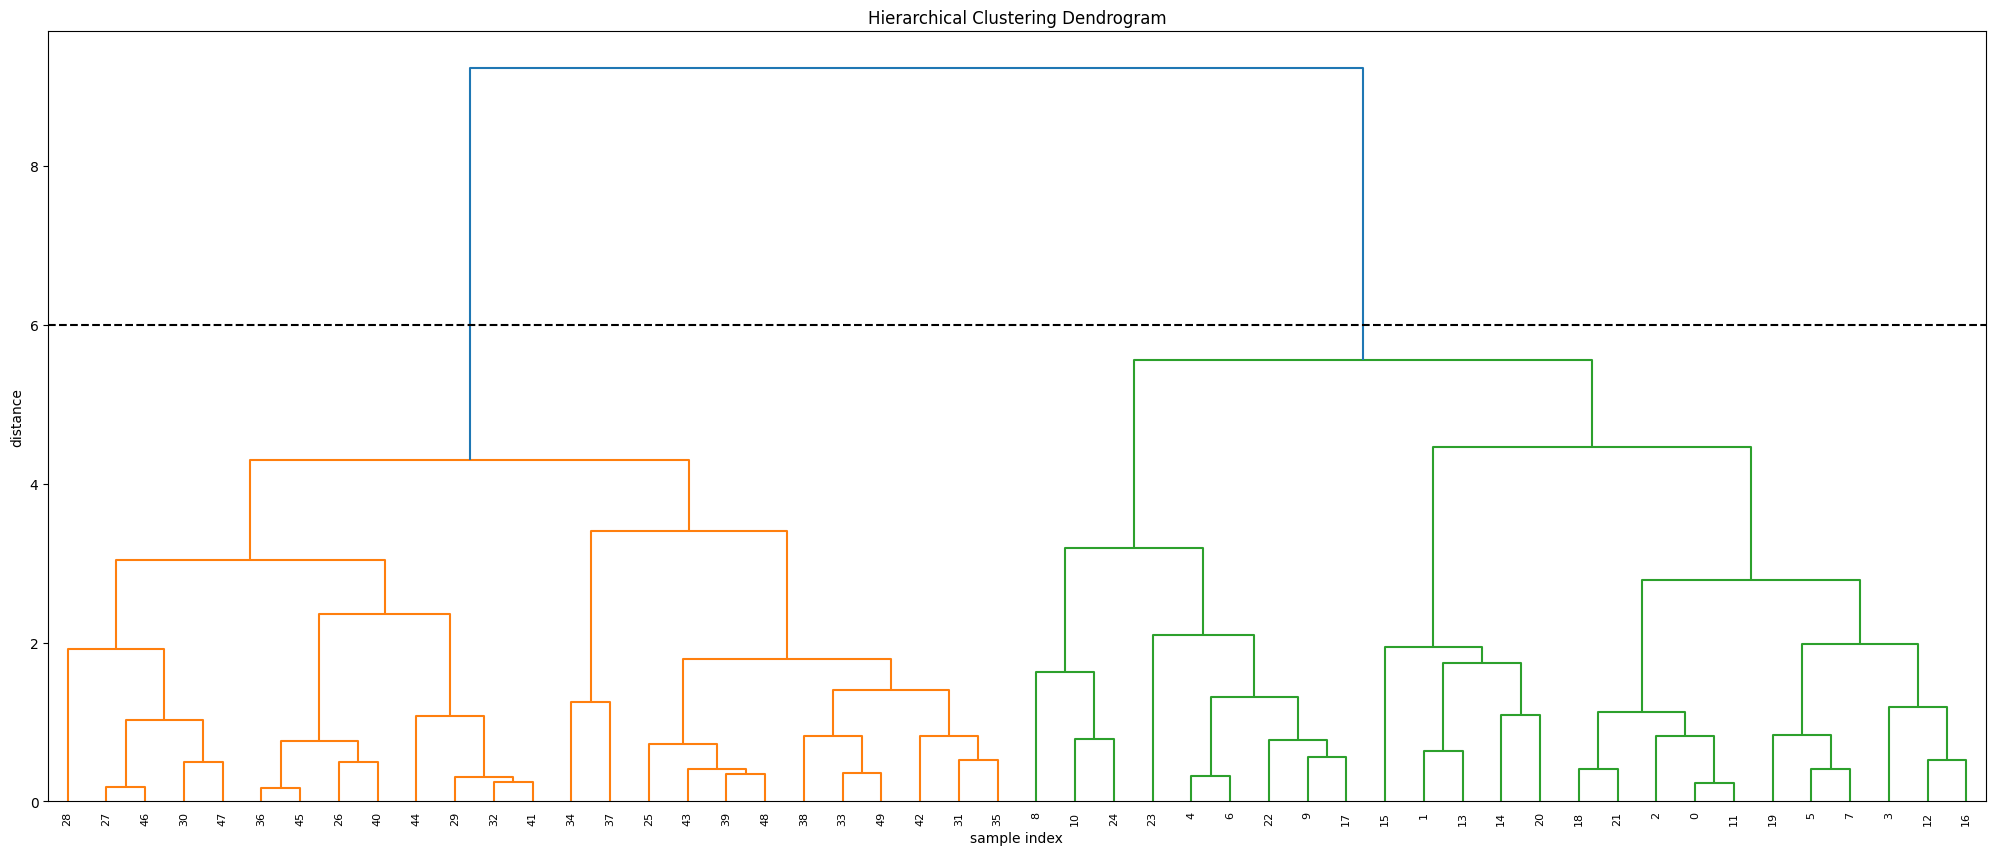

In [15]:
np.random.seed(123)
X = np.random.randn(50,2)
X[0:25, 0] = X[0:25, 0] + 3
X[0:25, 1] = X[0:25, 1] - 4

from scipy.cluster.hierarchy import linkage
hc_complete = linkage(X, "complete")# 簇会比较紧凑
hc_average = linkage(X, "average")# 既不太紧也不太松
hc_single = linkage(X, "single")# 形成“链状”簇

from scipy.cluster.hierarchy import dendrogram

# calculate full dendrogram
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    hc_complete,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.axhline(y=6, c='k', ls='dashed')
plt.show()

In [85]:
from scipy.cluster.hierarchy import cut_tree
print(cut_tree(hc_single, n_clusters = 4).T) # Printing transpose just for space

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 2 2 2 2 2 2 2 2 2 2 2
  2 3 2 2 2 2 2 2 2 2 2 2 2 2]]


### EM

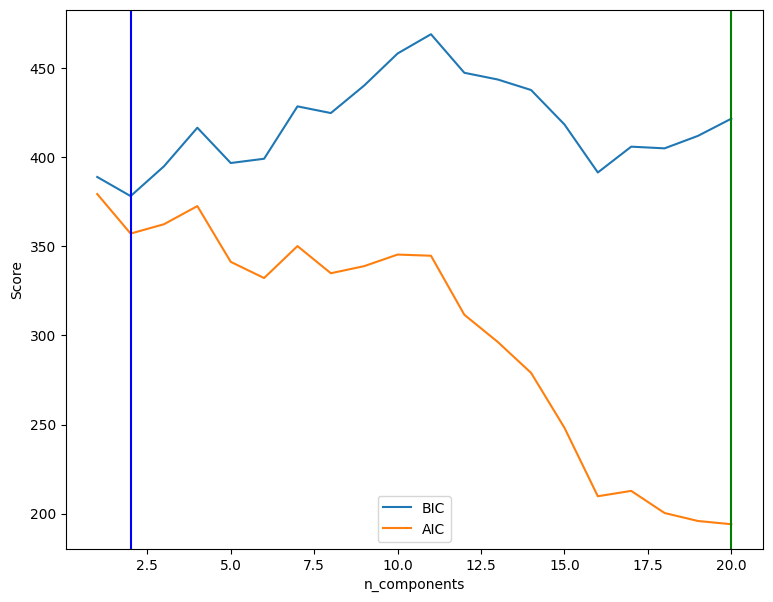

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

X = np.random.randn(50,2)
X[0:25, 0] = X[0:25, 0] + 3
X[0:25, 1] = X[0:25, 1] - 4
data=X

# the number of clustering
n_components = np.arange(1, 21)

# train GaussianMixture for each group
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(data)
          for n in n_components]

fig, ax = plt.subplots(figsize=(9,7))

# change for aic and bic
ax.plot(n_components, [m.bic(data) for m in models], label='BIC')
ax.plot(n_components, [m.aic(data) for m in models], label='AIC')

# find the least aic and bic automatically
ax.axvline(np.argmin([m.bic(data) for m in models]) + 1, color='blue')
ax.axvline(np.argmin([m.aic(data) for m in models]) + 1, color='green')

plt.legend(loc='best')
plt.xlabel('n_components')
plt.ylabel('Score') 
plt.show()

## Neural network

In [17]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']
irisdata = pd.read_csv(url, names=names)  
X = irisdata.iloc[:, 0:4]
y = irisdata.select_dtypes(include=[object])  

from sklearn import preprocessing  
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)

from sklearn.model_selection import train_test_split  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20) 

## scale the features
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()  
X_train = scaler.fit_transform(X_train)  
X_test = scaler.transform(X_test)  

D:\install\anaconda\envs\good\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [24]:
## train a neural network
from sklearn.neural_network import MLPClassifier  
mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10),# 3 layers and 10*10*10 neurals
                    max_iter=1000)  
mlp.fit(X_train, y_train.ravel())
predictions = mlp.predict(X_test)  

from sklearn.metrics import classification_report, confusion_matrix,r2_score
print(confusion_matrix(y_test,predictions))  
print(classification_report(y_test,predictions))  

[[ 8  0  0]
 [ 0 12  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



D:\install\anaconda\envs\good\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


(0.10945734477924561, 0.8162096822736549)

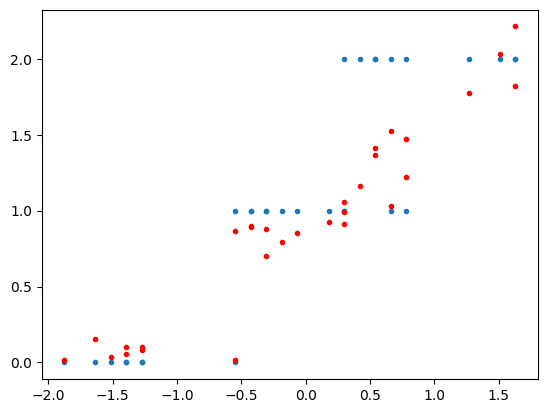

In [25]:
from sklearn.neural_network import MLPRegressor

##Single hidden layer, with 16 nodes and relu activation function
mlp = MLPRegressor(random_state=0, 
                   activation='relu',
                   hidden_layer_sizes=16)# one layer and 16 neurals
mlp.fit(X_train, y_train)

y_guess = mlp.predict(X_test)

plt.plot(X_test[:,0], y_test, '.')
plt.plot(X_test[:,0], y_guess, 'r.')

mean_squared_error(y_test, y_guess), r2_score(y_test, y_guess)

# Model selection and evaluation

## Crossvalidation

### Polynomial feature

In [108]:
import sklearn.linear_model as skl_lm
df1 = pd.read_csv('data/auto.csv', na_values='?').dropna()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


In [105]:
train_df = df1.sample(196, random_state = 1)
test_df = df1[~df1.isin(train_df)].dropna(how = 'all')

X_train = train_df['horsepower'].values.reshape(-1,1)
y_train = train_df['mpg']
X_test = test_df['horsepower'].values.reshape(-1,1)
y_test = test_df['mpg']

lm = skl_lm.LinearRegression()
model = lm.fit(X_train, y_train)
pred = model.predict(X_test)

In [106]:
from sklearn.metrics import mean_squared_error

MSE = mean_squared_error(y_test, pred)
print(MSE)

23.361902892587224


In [107]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)
X_train3 = poly.fit_transform(X_train)
X_test3 = poly.fit_transform(X_test)

model = lm.fit(X_train3, y_train)
print(mean_squared_error(y_test, model.predict(X_test3)))

20.325609365972525


### CV

In [7]:
portfolio_df = pd.read_csv('data/portfolio.csv')
x = np.random.rand(50, 1) 
y = np.random.rand(50)
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

from sklearn.model_selection import cross_val_score, LeaveOneOut
loo = LeaveOneOut()
loo.get_n_splits(x)
scores = cross_val_score(lm, x, y,
                         scoring="neg_mean_squared_error",
                         cv=loo, n_jobs=1)

print("Folds: " + str(len(scores)) + ", MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))

Folds: 50, MSE: 0.07256658323922006, STD: 0.07793005837604192


In [8]:
from sklearn.model_selection import KFold

crossvalidation = KFold(n_splits=50, random_state=None, shuffle=False) # N=392
model = lm.fit(x, y)
scores = cross_val_score(model, x, y, scoring="neg_mean_squared_error", cv=crossvalidation,n_jobs=1)

print("Folds: " + str(len(scores)) + ", MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))

Folds: 50, MSE: 0.07256658323922006, STD: 0.07793005837604192


In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
crossvalidation = KFold(n_splits=10, shuffle=False)
df1 = pd.read_csv('data/auto.csv', na_values='?').dropna()
X = df1['horsepower'].values.reshape(-1,1)
y = df1['mpg'].values.reshape(-1,1)
lm = LinearRegression()

for i in range(1,6):
    poly = PolynomialFeatures(degree=i)
    X_current = poly.fit_transform(X)
    model = lm.fit(X_current, y)
    scores = cross_val_score(model, X_current, y, scoring="neg_mean_squared_error", cv=crossvalidation,
 n_jobs=1)
    
    print("Degree-"+str(i)+" polynomial MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))

Degree-1 polynomial MSE: 27.439933652339864, STD: 14.510250711281135
Degree-2 polynomial MSE: 21.235840055801585, STD: 11.797327528897467
Degree-3 polynomial MSE: 21.336606183331117, STD: 11.844339714581873
Degree-4 polynomial MSE: 21.353886976174397, STD: 11.986332284638403
Degree-5 polynomial MSE: 20.905558642375237, STD: 12.185448360778402


## Booststrap

In [116]:
portfolio_df = pd.read_csv('data/portfolio.csv')
portfolio_df.head()

,Unnamed: 0,X,Y
0,1,-0.895251,-0.234924
1,2,-1.562454,-0.885176
2,3,-0.417090,0.271888
3,4,1.044356,-0.734198
4,5,-0.315568,0.841983


In [121]:
def alpha(X,Y):
    return ((np.var(Y)-np.cov(X,Y))/(np.var(X)+np.var(Y)-2*np.cov(X,Y)))

X = portfolio_df.X[0:100]
y = portfolio_df.Y[0:100]
print(alpha(X,y))

# Xsamp, ysamp = resample(X, y, n_samples=1000)
dfsample = portfolio_df.sample(frac=1, replace=True)
X = dfsample.X[0:100]
y = dfsample.Y[0:100]
print(alpha(X,y))

[[1.07270947 0.57665115]
 [0.57665115 0.06414064]]
[[ 0.91741558  0.44338571]
 [ 0.44338571 -0.1080099 ]]


In [120]:
def bstrap(df):# 1000 times booststrap
    tresult = 0
    for i in range(0,1000):
        dfsample = df.sample(frac=1, replace=True)
        X = dfsample.X[0:100]
        y = dfsample.Y[0:100]
        result = alpha(X,y)
        tresult += result
    fresult = tresult / 1000
    print(fresult)
    
bstrap(portfolio_df)

[[0.82955665 0.57807599]
 [0.57807599 0.05092964]]
